In [1]:
#!pip install pybaseball pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import statcast_batter, playerid_lookup

data dictionary: https://baseballsavant.mlb.com/csv-docs 

Inspired by this article: https://www.mlb.com/news/why-batters-do-damage-when-they-hit-the-ball-out-front 

In [3]:
playerid_lookup('Soto', 'Juan')

,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,soto,juan,665742,sotoj001,sotoju01,20123,2018.0,2025.0


In [4]:
batter_id = 665742
df = statcast_batter(start_dt='2021-03-28', end_dt='2025-09-30', player_id=batter_id)

Gathering Player Data


In [5]:
batted = df[df['launch_speed'].notnull()].copy()

# Soto chart balls 100mph exit velo or above

C:\Users\manif\AppData\Local\Temp\ipykernel_14320\992076868.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([


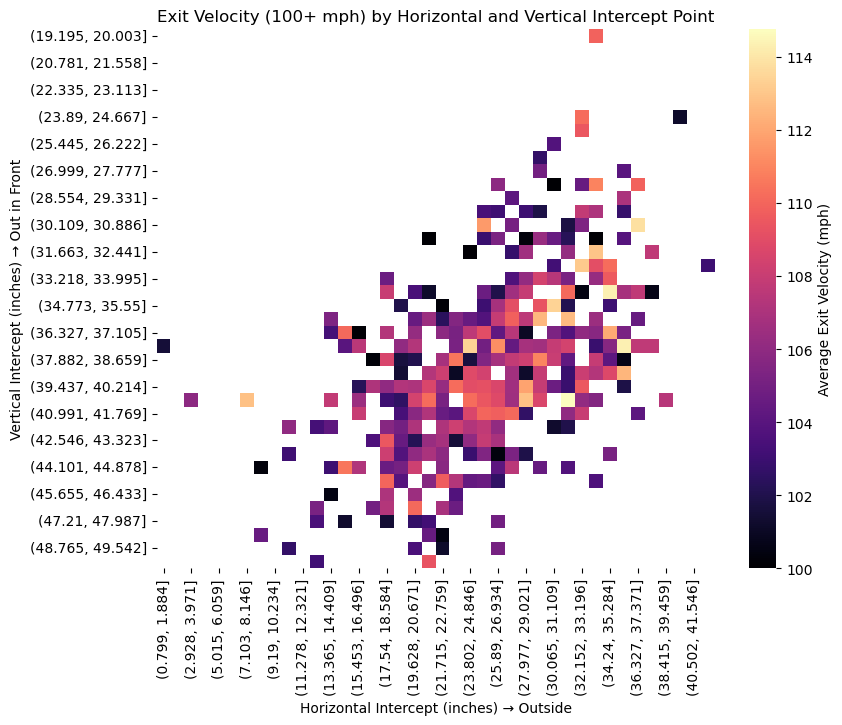

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for batted balls with exit velocity >= 100 mph
batted_100_plus = batted[
    (batted['launch_speed'] >= 100)
]

# Drop rows with missing intercepts or speeds
batted_clean = batted_100_plus.dropna(subset=[
    'intercept_ball_minus_batter_pos_x_inches',
    'intercept_ball_minus_batter_pos_y_inches',
    'launch_speed'
])

# Create 2D bins
heatmap_data = (
    batted_clean
    .groupby([
        pd.cut(batted_clean['intercept_ball_minus_batter_pos_x_inches'], bins=40),
        pd.cut(batted_clean['intercept_ball_minus_batter_pos_y_inches'], bins=40)
    ])['launch_speed']
    .mean()
    .unstack()
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    cmap='magma',
    cbar_kws={'label': 'Average Exit Velocity (mph)'},
)
plt.title("Exit Velocity (100+ mph) by Horizontal and Vertical Intercept Point")
plt.xlabel("Horizontal Intercept (inches) → Outside")
plt.ylabel("Vertical Intercept (inches) → Out in Front")
plt.show()

# Soto chart 100 mph exit velo and "sweet spot" launch angle defined by MLB (8-32)

C:\Users\manif\AppData\Local\Temp\ipykernel_14320\159317216.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([


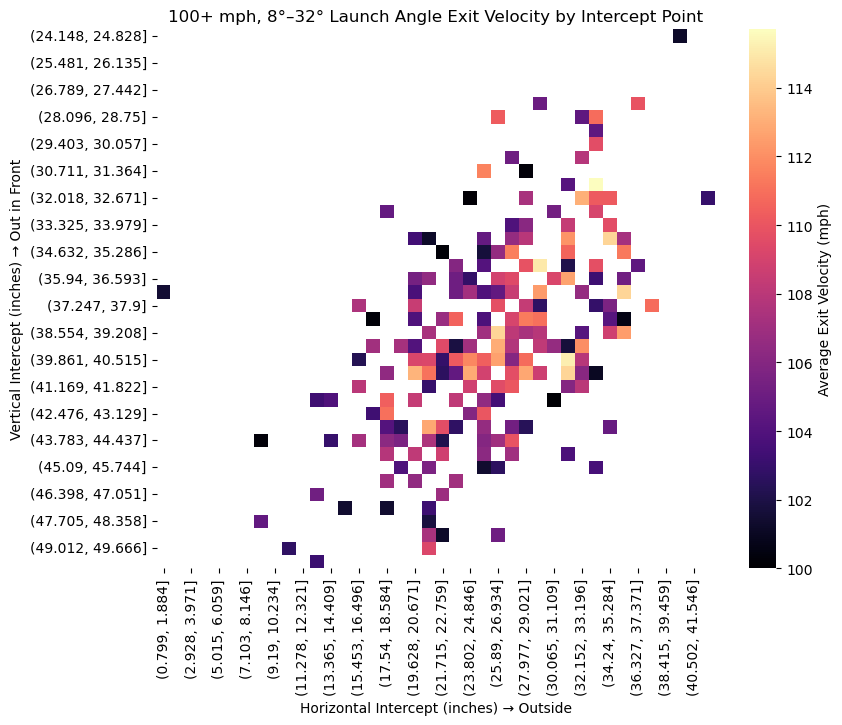

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for batted balls with exit velocity >= 100 mph and launch angle between 8-32 degrees
batted_filtered = batted[
    (batted['launch_speed'] >= 100) &
    (batted['launch_angle'] >= 8) &
    (batted['launch_angle'] <= 32)
]

# Drop rows with missing intercepts or speeds
batted_clean = batted_filtered.dropna(subset=[
    'intercept_ball_minus_batter_pos_x_inches',
    'intercept_ball_minus_batter_pos_y_inches',
    'launch_speed'
])

# Create 2D bins
heatmap_data = (
    batted_clean
    .groupby([
        pd.cut(batted_clean['intercept_ball_minus_batter_pos_x_inches'], bins=40),
        pd.cut(batted_clean['intercept_ball_minus_batter_pos_y_inches'], bins=40)
    ])['launch_speed']
    .mean()
    .unstack()
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    cmap='magma',
    cbar_kws={'label': 'Average Exit Velocity (mph)'},
)
plt.title("100+ mph, 8°–32° Launch Angle Exit Velocity by Intercept Point")
plt.xlabel("Horizontal Intercept (inches) → Outside")
plt.ylabel("Vertical Intercept (inches) → Out in Front")
plt.show()

Regression line slope: -0.716 inches deeper in the zone per 1 inch outside


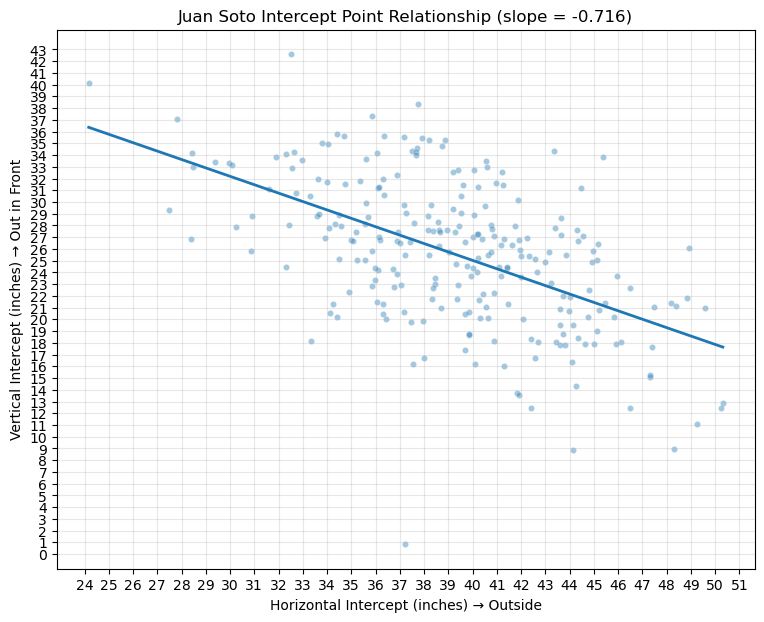

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Filter for batted balls with exit velocity >= 100 mph and launch angle between 8–32 degrees
batted_filtered = batted[
    (batted['launch_speed'] >= 100) &
    (batted['launch_angle'] >= 8) &
    (batted['launch_angle'] <= 32)
]

# Drop rows with missing intercept values
batted_clean = batted_filtered.dropna(subset=[
    'intercept_ball_minus_batter_pos_x_inches',
    'intercept_ball_minus_batter_pos_y_inches'
])

# Extract x and y variables
x = batted_clean['intercept_ball_minus_batter_pos_x_inches']
y = batted_clean['intercept_ball_minus_batter_pos_y_inches']

# Calculate the regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Print the slope
print(f"Regression line slope: {slope:.3f} inches deeper in the zone per 1 inch outside")

# Create plot
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=x,
    y=y,
    alpha=0.4,
    s=20
)

sns.regplot(
    x=x,
    y=y,
    scatter=False,
    line_kws={'linewidth': 2},
    ci=None
)

plt.title(f"Juan Soto Intercept Point Relationship (slope = {slope:.3f})")
plt.xlabel("Horizontal Intercept (inches) → Outside")
plt.ylabel("Vertical Intercept (inches) → Out in Front")

# Set x and y axis ticks to every 1 inch
plt.xticks(np.arange(np.floor(x.min()), np.ceil(x.max()) + 1, 1))
plt.yticks(np.arange(np.floor(y.min()), np.ceil(y.max()) + 1, 1))

plt.grid(alpha=0.3)
plt.show()

# Getting MLB average

In [9]:
from pybaseball import statcast

# Grab league-wide Statcast data for a shorter period (to avoid massive downloads)
df = statcast(start_dt="2024-03-28", end_dt="2024-10-01")

# Get unique player IDs
player_ids = df['batter'].dropna().unique()
print(len(player_ids))  # How many players during this time?
print(player_ids[:10])  # Show first few IDs

This is a large query, it may take a moment to complete


100%|████████████████████████████████████████████████████████████████████████████████| 188/188 [00:38<00:00,  4.85it/s]
E:\Anaconda\Lib\site-packages\pybaseball\statcast.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_data = pd.concat(dataframe_list, axis=0).convert_dtypes(convert_string=False)


651
<IntegerArray>
[518792, 676801, 605170, 665161, 673237, 608324, 670541, 672761, 690993,
 682985]
Length: 10, dtype: Int64


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pybaseball import statcast_batter

# Download data per player (to avoid large downloads)
batted_list = []

for player_id in player_ids:
    try:
        player_data = statcast_batter(
            start_dt="2024-03-28", 
            end_dt="2024-10-01", 
            player_id=player_id
        )
        batted_list.append(player_data)
    except Exception as e:
        print(f"Error fetching data for player {player_id}: {e}")

# Merge all player data into a single DataFrame
batted = pd.concat(batted_list, ignore_index=True)
batted = batted[batted['launch_speed'].notnull()].copy()

# Calculate max exit velocity per player per year
batted['game_year'] = pd.to_datetime(batted['game_date']).dt.year
max_ev_per_player = (
    batted.groupby(['player_name', 'game_year'])['launch_speed']
    .max()
    .reset_index(name='max_ev')
)

# Merge max ev back with the main data
batted = batted.merge(
    max_ev_per_player,
    on=['player_name', 'game_year'],
    how='left'
)

# Filter swings ≥ 90% of each player's max EV
threshold = 0.90
batted['qualifying_ev'] = batted['launch_speed'] >= (threshold * batted['max_ev'])

# Filter on launch angle
filtered_batted = batted[
    (batted['qualifying_ev']) &
    (batted['launch_angle'] >= 8) &
    (batted['launch_angle'] <= 32)
]

# Clean and drop NaNs in contact points
filtered_batted = filtered_batted.dropna(subset=[
    'intercept_ball_minus_batter_pos_x_inches',
    'intercept_ball_minus_batter_pos_y_inches'
])

# Plot the regression between horizontal and vertical contact points
plt.figure(figsize=(9, 7))
sns.regplot(
    data=filtered_batted,
    x='intercept_ball_minus_batter_pos_x_inches',
    y='intercept_ball_minus_batter_pos_y_inches',
    scatter_kws={'alpha': 0.3, 's': 10},
)
plt.title("MLB Average: Horizontal vs Vertical Contact Point\n(Filtered by 90% of Max EV, LA 8-32°)")
plt.xlabel("Horizontal Intercept (inches) → Outside")
plt.ylabel("Vertical Intercept (inches) → Out in Front")
plt.xticks(np.arange(
    int(filtered_batted['intercept_ball_minus_batter_pos_x_inches'].min()),
    int(filtered_batted['intercept_ball_minus_batter_pos_x_inches'].max()) + 1,
    1
))
plt.yticks(np.arange(
    int(filtered_batted['intercept_ball_minus_batter_pos_y_inches'].min()),
    int(filtered_batted['intercept_ball_minus_batter_pos_y_inches'].max()) + 1,
    1
))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Choose a path
save_path = r"E:\Baseball\Data\filtered_batted_2024.parquet"

filtered_batted.to_parquet(save_path, index=False)
print("Saved filtered_batted to Parquet.")

In [10]:
import pandas as pd

load_path = r"E:\Baseball\Data\filtered_batted_2024.parquet"

filtered_batted = pd.read_parquet(load_path)
print("Loaded filtered_batted from disk:", filtered_batted.shape)


Loaded filtered_batted from disk: (15229, 120)


In [11]:
filtered_batted["intercept_ball_minus_batter_pos_x_inches"].mean()

np.float64(35.95508808731859)

In [12]:
filtered_batted["intercept_ball_minus_batter_pos_x_inches"].isna().sum()

np.int64(0)

In [13]:
for c in filtered_batted.columns:
    print(c)

pitch_type
game_date
release_speed
release_pos_x
release_pos_z
player_name
batter
pitcher
events
description
spin_dir
spin_rate_deprecated
break_angle_deprecated
break_length_deprecated
zone
des
game_type
stand
p_throws
home_team
away_team
type
hit_location
bb_type
balls
strikes
game_year
pfx_x
pfx_z
plate_x
plate_z
on_3b
on_2b
on_1b
outs_when_up
inning
inning_topbot
hc_x
hc_y
tfs_deprecated
tfs_zulu_deprecated
umpire
sv_id
vx0
vy0
vz0
ax
ay
az
sz_top
sz_bot
hit_distance_sc
launch_speed
launch_angle
effective_speed
release_spin_rate
release_extension
game_pk
fielder_2
fielder_3
fielder_4
fielder_5
fielder_6
fielder_7
fielder_8
fielder_9
release_pos_y
estimated_ba_using_speedangle
estimated_woba_using_speedangle
woba_value
woba_denom
babip_value
iso_value
launch_speed_angle
at_bat_number
pitch_number
pitch_name
home_score
away_score
bat_score
fld_score
post_away_score
post_home_score
post_bat_score
post_fld_score
if_fielding_alignment
of_fielding_alignment
spin_axis
delta_home_win_exp
d

In [14]:
from scipy.stats import linregress

# Calculate regression statistics
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_batted['intercept_ball_minus_batter_pos_x_inches'],
    filtered_batted['intercept_ball_minus_batter_pos_y_inches']
)

print(f"Slope: {slope:.4f} inches vertical change per inch horizontal")
print(f"Intercept: {intercept:.2f} inches")
print(f"R-squared: {r_value**2:.4f}")

Slope: -0.6487 inches vertical change per inch horizontal
Intercept: 55.32 inches
R-squared: 0.2494


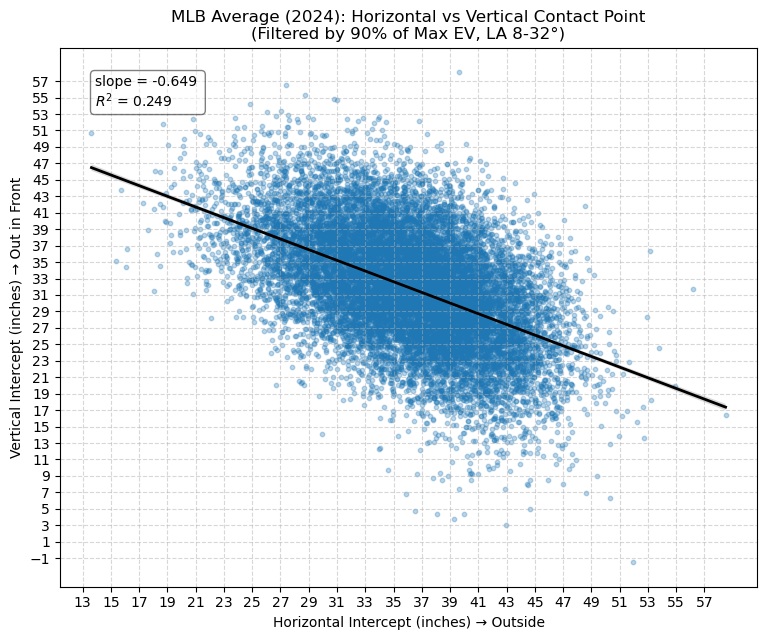

In [15]:
from scipy.stats import linregress

# Calculate regression values
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_batted['intercept_ball_minus_batter_pos_x_inches'],
    filtered_batted['intercept_ball_minus_batter_pos_y_inches']
)

# Replot with ticks every 2 inches
plt.figure(figsize=(9, 7))
sns.regplot(
    data=filtered_batted,
    x='intercept_ball_minus_batter_pos_x_inches',
    y='intercept_ball_minus_batter_pos_y_inches',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'black', 'linewidth': 2}  # Change line color and thickness here

)
plt.title("MLB Average (2024): Horizontal vs Vertical Contact Point\n(Filtered by 90% of Max EV, LA 8-32°)")
plt.xlabel("Horizontal Intercept (inches) → Outside")
plt.ylabel("Vertical Intercept (inches) → Out in Front")

# Add regression equation as text
eq_text = f"slope = {slope:.3f} \n$R^2$ = {r_value**2:.3f}"
plt.text(
    0.05, 0.95, 
    eq_text, 
    transform=plt.gca().transAxes, 
    fontsize=10, 
    verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

# Set ticks every 2 inches
plt.xticks(np.arange(
    int(filtered_batted['intercept_ball_minus_batter_pos_x_inches'].min()),
    int(filtered_batted['intercept_ball_minus_batter_pos_x_inches'].max()) + 1,
    2
))
plt.yticks(np.arange(
    int(filtered_batted['intercept_ball_minus_batter_pos_y_inches'].min()),
    int(filtered_batted['intercept_ball_minus_batter_pos_y_inches'].max()) + 1,
    2
))

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [16]:
# Automatically collect filtered data for all players
player_data_filtered = {}

for player_name, df in batted.groupby('player_name'):
    # Compute max EV per year
    df['max_ev'] = df.groupby('game_year')['launch_speed'].transform('max')

    # Apply your filters
    filtered = df[
        (df['launch_speed'] >= 0.9 * df['max_ev']) &
        (df['launch_angle'].between(8, 32)) &
        (df['intercept_ball_minus_batter_pos_x_inches'].notna()) &
        (df['intercept_ball_minus_batter_pos_y_inches'].notna())
    ].copy()

    # Only keep players with enough data points
    if len(filtered) >= 40:  
        player_data_filtered[player_name] = filtered


In [17]:
from sklearn.linear_model import LinearRegression
import pandas as pd

def compute_slopes_for_all_players(filtered_data_dict):
    results = []

    for player, df in filtered_data_dict.items():

        # Clean NaN values
        df = df.dropna(subset=[
            'intercept_ball_minus_batter_pos_x_inches',
            'intercept_ball_minus_batter_pos_y_inches'
        ])

        if df.shape[0] < 10:
            continue

        X = df['intercept_ball_minus_batter_pos_x_inches'].values.reshape(-1, 1)
        y = df['intercept_ball_minus_batter_pos_y_inches'].values

        model = LinearRegression().fit(X, y)

        slope = model.coef_[0]
        r2 = model.score(X, y)

        results.append({
            'player_name': player,
            'slope': slope,
            'r_squared': r2,
            'n_samples': df.shape[0]
        })

    return pd.DataFrame(results)


In [18]:
slope_table = compute_slopes_for_all_players(player_data_filtered)

Corbin Carroll adjusts 1.3 inches of contact depth for every 1 inch of horizontal pitch difference.

That is an extremely large and athletic depth adjustment.

Most MLB hitters adjust somewhere around 0.45–0.75 inches per inch horizontally.

Carroll is nearly double that.

In [19]:
slope_table.sort_values(by='slope').head(10)

,player_name,slope,r_squared,n_samples
0,"Soto, Juan",-0.699531,0.309333,178


For Lowe:

A 3-inch difference in horizontal pitch location only changes contact depth by

3 * 0.12 = 0.36 inches


which is almost negligible.

He keeps his barrel much more level and consistent, regardless of pitch location.

In [20]:
slope_table.sort_values(by='slope', ascending=False).head(10)

,player_name,slope,r_squared,n_samples
0,"Soto, Juan",-0.699531,0.309333,178


In [21]:
# Filter by r^2 threshold
r2_filtered = slope_table[slope_table['r_squared'] >= 0.40]
print("Players with R² >= 0.40:", r2_filtered.shape)

Players with R² >= 0.40: (0, 4)


In [22]:
lowest_slopes = r2_filtered.sort_values(by='slope').head(10)
print("Lowest Slopes (R² >= 0.40):")
display(lowest_slopes)

Lowest Slopes (R² >= 0.40):


,player_name,slope,r_squared,n_samples


In [23]:
highest_slopes = r2_filtered.sort_values(by='slope', ascending=False).head(10)
print("Highest Slopes (R² >= 0.40):")
display(highest_slopes)

Highest Slopes (R² >= 0.40):


,player_name,slope,r_squared,n_samples


# Comparing players with different levers (the higher absolute value of the slope, the more further back contact is made)

y = slope*x

Where:

x = how inside/outside the ball was contacted

y = how far out in front / deep the ball was contacted

Statcast defines these as ball contact point relative to the hitter's center of mass.

Gathering Player Data
Gathering Player Data
Gathering Player Data
Gathering Player Data
Gathering Player Data
Gathering Player Data


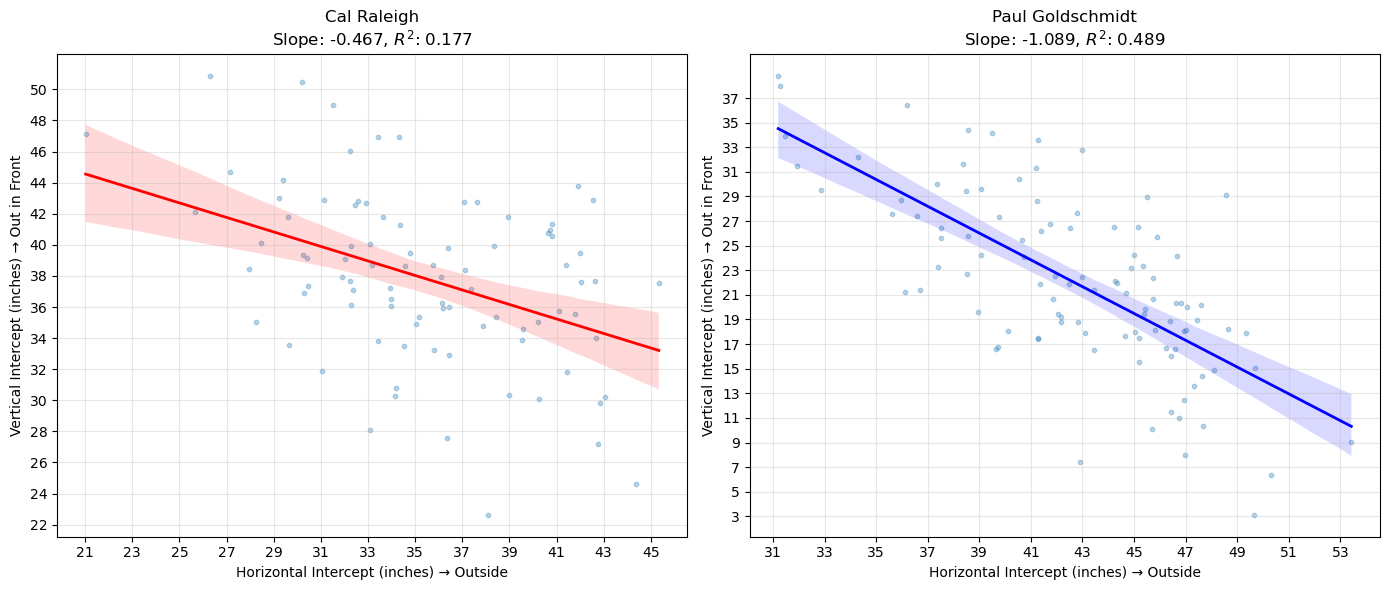

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pybaseball import statcast_batter
from sklearn.linear_model import LinearRegression

# === USER INPUT: Edit only this part ===
players = {
    'Cal Raleigh': 663728,
    'Paul Goldschmidt': 502671
}
years = [2022, 2023, 2024]  
# ========================================

# Load data for each player across specified years
def load_player_data(players, years):
    player_data = {}
    for name, player_id in players.items():
        all_years = []
        for year in years:
            print(f"Downloading {year} data for {name}...")
            data = statcast_batter(
                start_dt=f"{year}-03-28",
                end_dt=f"{year}-10-01",
                player_id=player_id
            )
            data['game_year'] = year
            all_years.append(data)
        df = pd.concat(all_years, ignore_index=True)
        df = df[df['launch_speed'].notnull()].copy()
        player_data[name] = df
    return player_data

# Filter based on 90% of max EV, launch angle, and intercept values
def filter_batted_ball_data(player_df, ev_threshold=0.9, min_la=8, max_la=32):
    player_df['max_ev'] = player_df.groupby('game_year')['launch_speed'].transform('max')
    filtered_df = player_df[
        (player_df['launch_speed'] >= ev_threshold * player_df['max_ev']) &
        (player_df['launch_angle'].between(min_la, max_la)) &
        (player_df['intercept_ball_minus_batter_pos_x_inches'].notna()) &
        (player_df['intercept_ball_minus_batter_pos_y_inches'].notna())
    ].copy()
    return filtered_df

# Compare two players' contact points on a side-by-side scatter + regression
def compare_contact_points(player1_data, player2_data, player1_name, player2_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    def plot_regression(ax, data, title, color):
        x = data['intercept_ball_minus_batter_pos_x_inches'].values.reshape(-1, 1)
        y = data['intercept_ball_minus_batter_pos_y_inches'].values
        model = LinearRegression().fit(x, y)
        slope = model.coef_[0]
        r_squared = model.score(x, y)

        sns.regplot(
            data=data,
            x='intercept_ball_minus_batter_pos_x_inches',
            y='intercept_ball_minus_batter_pos_y_inches',
            ax=ax,
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': color, 'linewidth': 2},
        )
        ax.set_title(f"{title}\nSlope: {slope:.3f}, $R^2$: {r_squared:.3f}")
        ax.set_xlabel("Horizontal Intercept (inches) → Outside")
        ax.set_ylabel("Vertical Intercept (inches) → Out in Front")
        ax.grid(alpha=0.3)
        ax.set_xticks(np.arange(int(data['intercept_ball_minus_batter_pos_x_inches'].min()),
                                int(data['intercept_ball_minus_batter_pos_x_inches'].max()) + 1, 2))
        ax.set_yticks(np.arange(int(data['intercept_ball_minus_batter_pos_y_inches'].min()),
                                int(data['intercept_ball_minus_batter_pos_y_inches'].max()) + 1, 2))

    plot_regression(axes[0], player1_data, player1_name, 'red')
    plot_regression(axes[1], player2_data, player2_name, 'blue')  

    plt.tight_layout()
    plt.show()

# === RUN EVERYTHING ===
player_data = load_player_data(players, years)
player_data_filtered = {name: filter_batted_ball_data(df) for name, df in player_data.items()}

# Plot comparison between first two players in the dict
player_names = list(players.keys())
compare_contact_points(
    player_data_filtered[player_names[0]],
    player_data_filtered[player_names[1]],
    player_names[0],
    player_names[1]
)

# Controlling for pitch type

In [25]:
def plot_contact_regression(df, pitch):
    pitch_df = df[df['pitch_type'] == pitch]

    slope, intercept, r_value, _, _ = linregress(
        pitch_df['intercept_ball_minus_batter_pos_x_inches'],
        pitch_df['intercept_ball_minus_batter_pos_y_inches']
    )

    plt.figure(figsize=(9, 7))
    sns.regplot(
        data=pitch_df,
        x='intercept_ball_minus_batter_pos_x_inches',
        y='intercept_ball_minus_batter_pos_y_inches',
        scatter_kws={'alpha': 0.3, 's': 10},
        line_kws={'color': 'black', 'linewidth': 2}
    )

    plt.title(
        f"{pitch} Contact Point Profile\n"
        f"Slope = {slope:.3f}, $R^2$ = {r_value**2:.3f}"
    )
    plt.xlabel("Horizontal Intercept (inches)")
    plt.ylabel("Vertical Intercept (inches)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


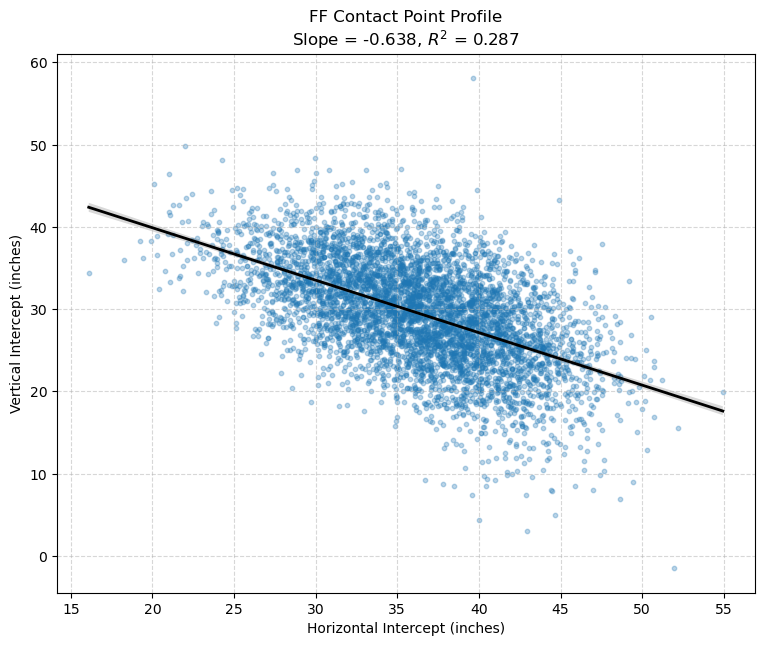

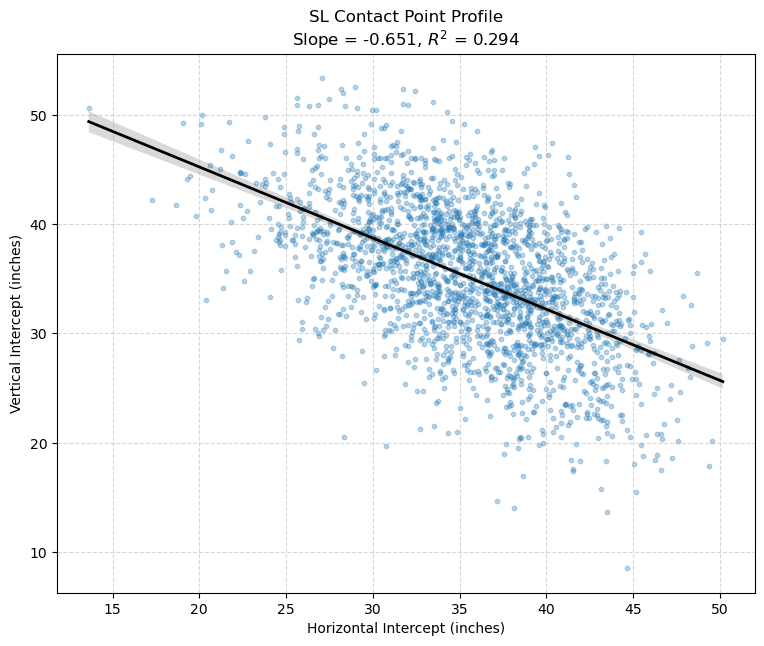

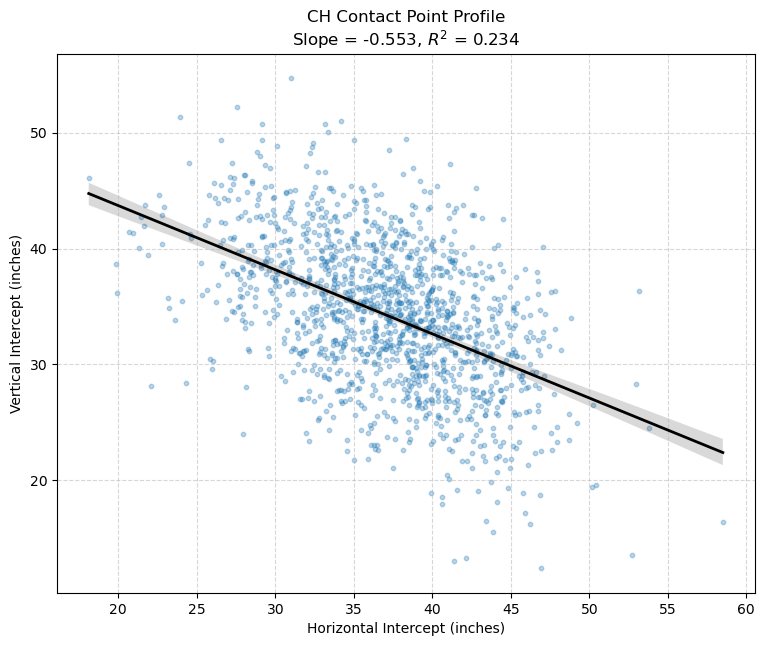

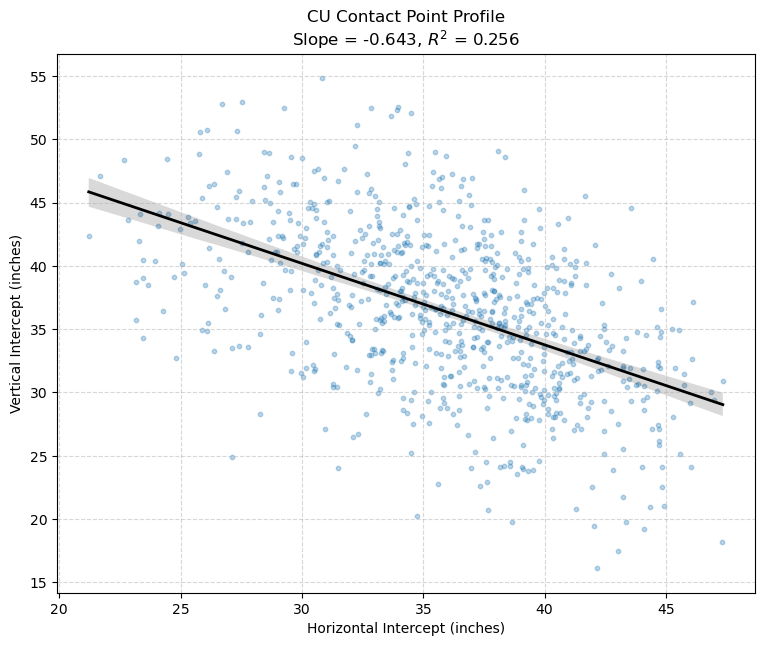

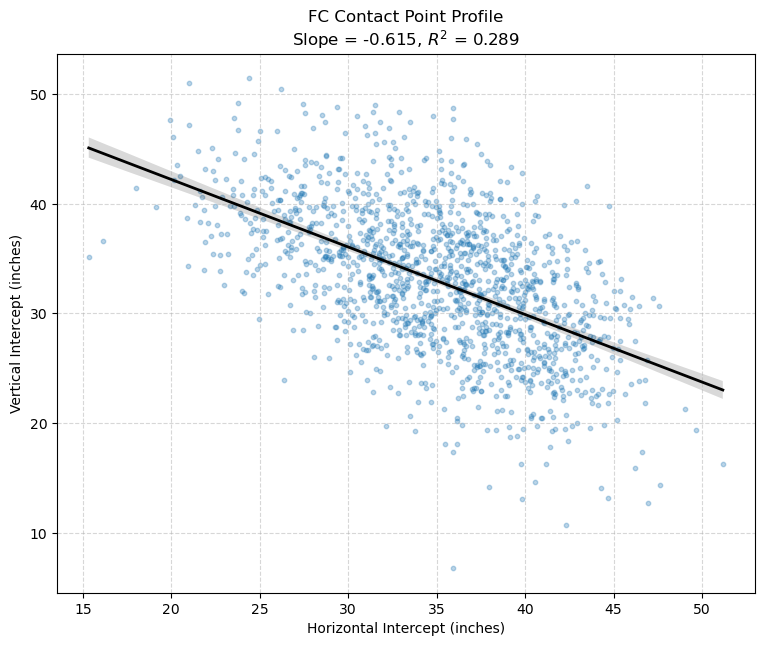

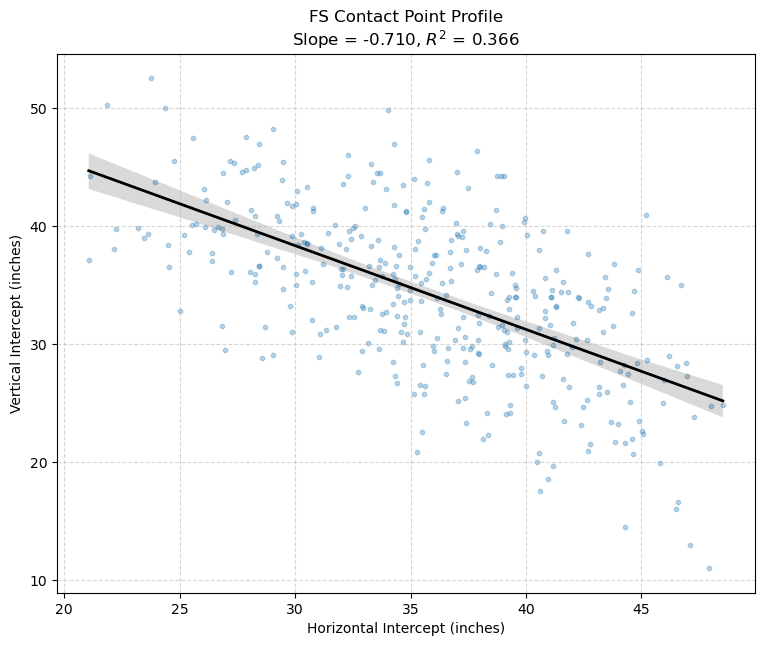

In [26]:
plot_contact_regression(filtered_batted, 'FF')
plot_contact_regression(filtered_batted, 'SL')
plot_contact_regression(filtered_batted, 'CH')
plot_contact_regression(filtered_batted, 'CU')
plot_contact_regression(filtered_batted, 'FC')
plot_contact_regression(filtered_batted, 'FS')

# Controlling for Pitch Type and Handedness

In [27]:
def filter_handedness(df, pitch=None, pitcher_hand=None, batter_hand=None):
    mask = pd.Series(True, index=df.index)

    if pitch is not None:
        mask &= df['pitch_type'] == pitch
    if pitcher_hand is not None:
        mask &= df['p_throws'] == pitcher_hand
    if batter_hand is not None:
        mask &= df['stand'] == batter_hand

    return df[mask]

In [28]:
# RHP vs LHB SL
df_rvl_sl = filter_handedness(
    filtered_batted,
    pitch='SL',
    pitcher_hand='R',
    batter_hand='L'
)

# RHP vs RHB SL
df_rvr_sl = filter_handedness(
    filtered_batted,
    pitch='SL',
    pitcher_hand='R',
    batter_hand='R'
)

# RHP vs LHB CH
df_rvl_ch = filter_handedness(
    filtered_batted,
    pitch='CH',
    pitcher_hand='R',
    batter_hand='L'
)

# RHP vs RHB Ch
df_rvr_ch = filter_handedness(
    filtered_batted,
    pitch='CH',
    pitcher_hand='R',
    batter_hand='R'
)
# RHP vs LHB sinker
df_rvl_fs = filter_handedness(
    filtered_batted,
    pitch='FS',
    pitcher_hand='R',
    batter_hand='L'
)

# RHP vs RHB sinker
df_rvr_fs = filter_handedness(
    filtered_batted,
    pitch='FS',
    pitcher_hand='R',
    batter_hand='R'
)



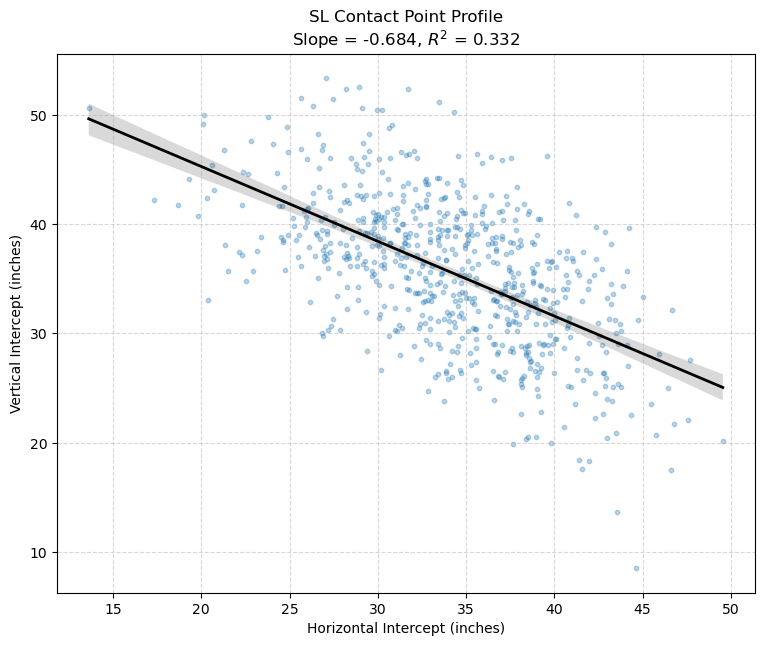

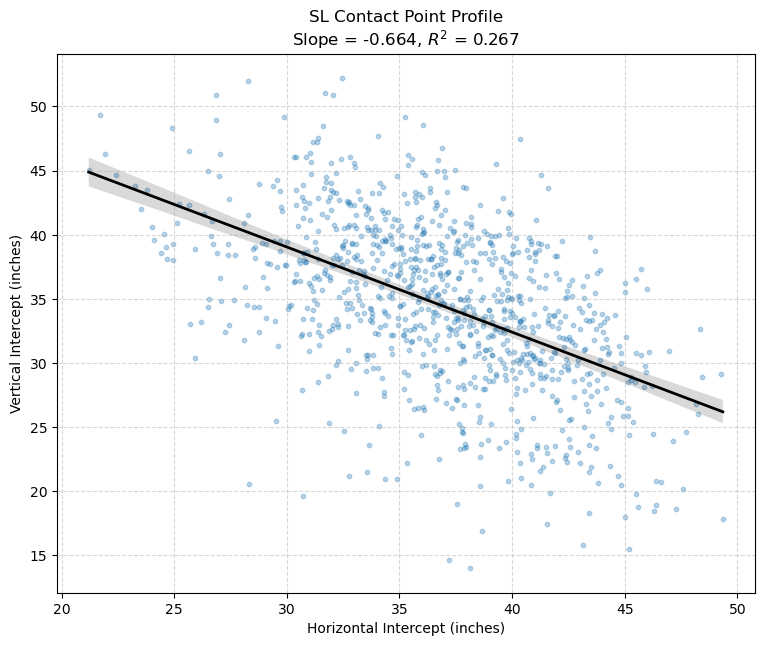

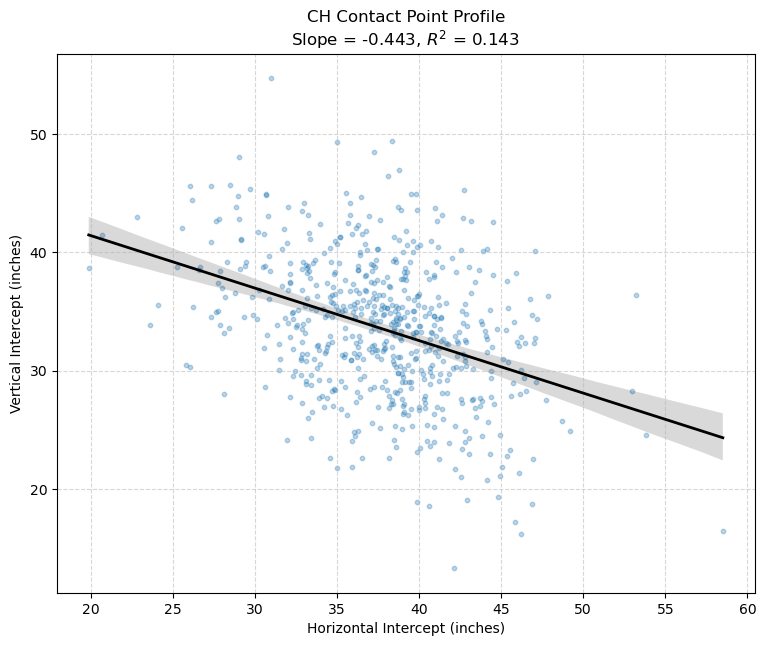

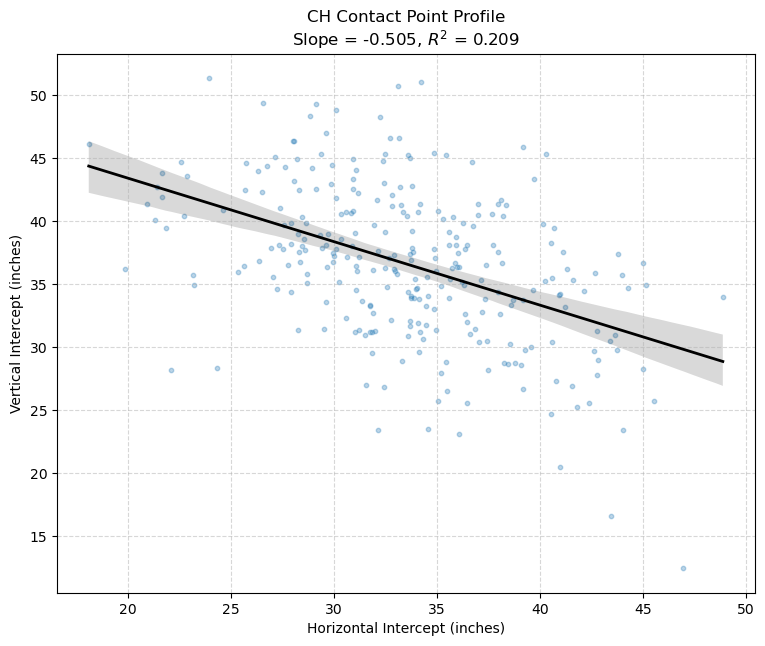

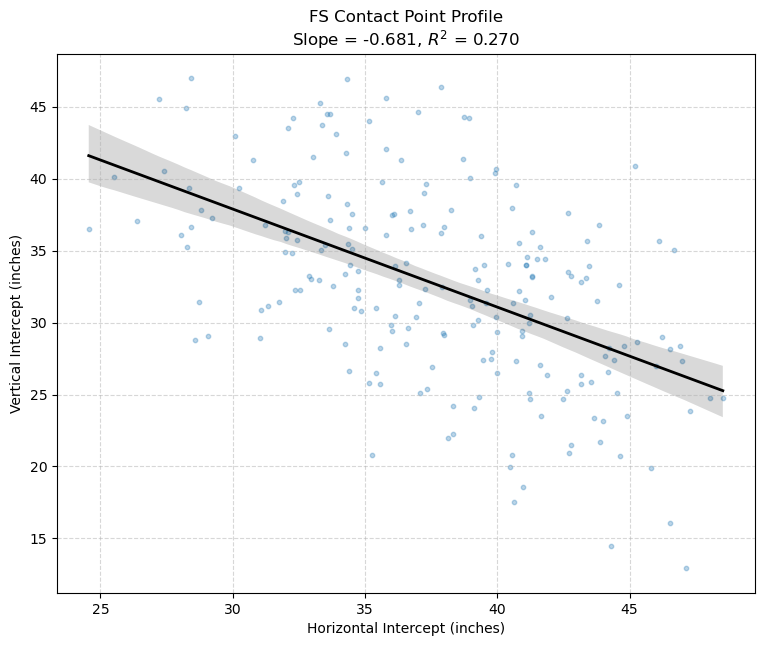

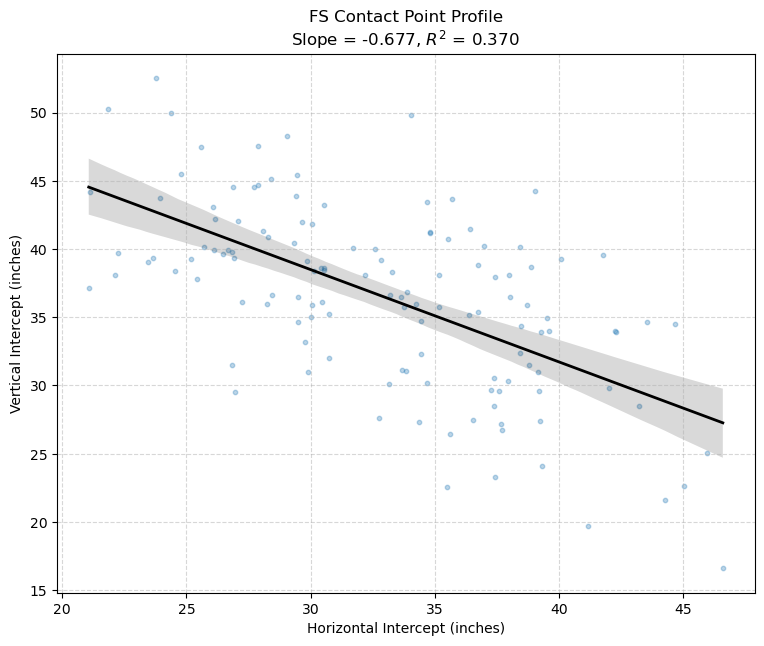

In [29]:
plot_contact_regression(
    df_rvl_sl,
    pitch='SL'
)
plot_contact_regression(
    df_rvr_sl,
    pitch='SL'
)
plot_contact_regression(
    df_rvl_ch,
    pitch='CH'
)
plot_contact_regression(
    df_rvr_ch,
    pitch='CH'
)
plot_contact_regression(
    df_rvl_fs,
    pitch='FS'
)
plot_contact_regression(
    df_rvr_fs,
    pitch='FS'
)

# Comparing pitches up vs down in the zone

In [30]:
print(filtered_batted['stand'].value_counts())


stand
R    8699
L    6530
Name: count, dtype: int64


In [31]:
filtered_batted_R = filtered_batted[filtered_batted['stand'] == 'R'].copy()

print("Right-handed hitter samples:", filtered_batted_R.shape)

Right-handed hitter samples: (8699, 120)


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_contact_height_heatmap(filtered_batted, x_bin=1, y_bin=1, min_count=20):
    cols = [
        "plate_z",
        "intercept_ball_minus_batter_pos_x_inches",
        "intercept_ball_minus_batter_pos_y_inches",
    ]
    df = filtered_batted[cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # Bin contact space
    df["x_bin"] = (df["intercept_ball_minus_batter_pos_x_inches"] // x_bin) * x_bin
    df["y_bin"] = (df["intercept_ball_minus_batter_pos_y_inches"] // y_bin) * y_bin

    agg = (
        df.groupby(["x_bin", "y_bin"])["plate_z"]
          .agg(["mean", "count"])
          .reset_index()
    )

    agg = agg[agg["count"] >= min_count]

    pivot = agg.pivot(index="y_bin", columns="x_bin", values="mean")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        pivot,
        cmap="viridis",
        cbar_kws={"label": "Average Pitch Height (plate_z, ft)"},
    )

    plt.xlabel("Horizontal Intercept (inches) → Outside")
    plt.ylabel("Vertical Intercept (inches) → Out in Front")
    plt.title("MLB-wide Contact Point Map\nColor = Average Pitch Height")
    plt.gca().invert_yaxis()
    plt.show()

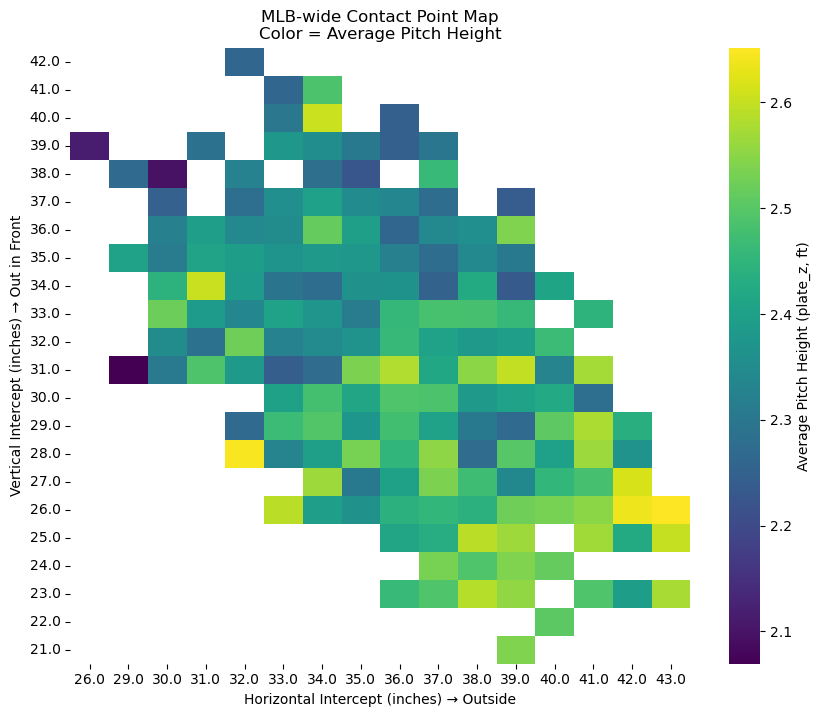

In [33]:
plot_contact_height_heatmap(filtered_batted_R)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

def plot_height_vs_depth_at_fixed_horizontal(
    filtered_batted,
    x_center,
    x_width=2,
    min_samples=50
):
    """
    x_center: center of horizontal band (inches)
    x_width: total width of band (± x_width/2)
    """

    # Keep required columns
    cols = [
        "plate_z",  # feet
        "intercept_ball_minus_batter_pos_x_inches",
        "intercept_ball_minus_batter_pos_y_inches",
    ]
    df = filtered_batted[cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # Filter horizontal band
    half = x_width / 2
    band = df[
        (df["intercept_ball_minus_batter_pos_x_inches"] >= x_center - half) &
        (df["intercept_ball_minus_batter_pos_x_inches"] <= x_center + half)
    ]

    n = band.shape[0]
    print(f"Samples in horizontal band [{x_center-half}, {x_center+half}]: {n}")

    if n < min_samples:
        print("Not enough samples — widen band or lower min_samples.")
        return

    # -----------------------------
    # REGRESSION (in / in)
    # -----------------------------

    # Convert pitch height from feet → inches
    X = (band["plate_z"] * 12).values.reshape(-1, 1)   # inches
    y = band["intercept_ball_minus_batter_pos_y_inches"].values

    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]   # in / in
    r2 = model.score(X, y)

    # -----------------------------
    # PLOT
    # -----------------------------

    plt.figure(figsize=(8, 6))
    sns.regplot(
        x=X.flatten(),   # inches
        y=y,
        scatter_kws={"alpha": 0.35, "s": 12},
        line_kws={"color": "red", "linewidth": 2},
    )

    plt.xlabel("Pitch Height (inches)")
    plt.ylabel("Vertical Intercept (inches) → Out in Front")
    plt.title(
        f"Fixed Horizontal Contact ≈ {x_center} ± {half} in\n"
        f"Depth vs Pitch Height | slope={slope:.3f} in/in, R²={r2:.2f}"
    )
    plt.grid(alpha=0.3)
    plt.show()

Samples in horizontal band [31.0, 33.0]: 875


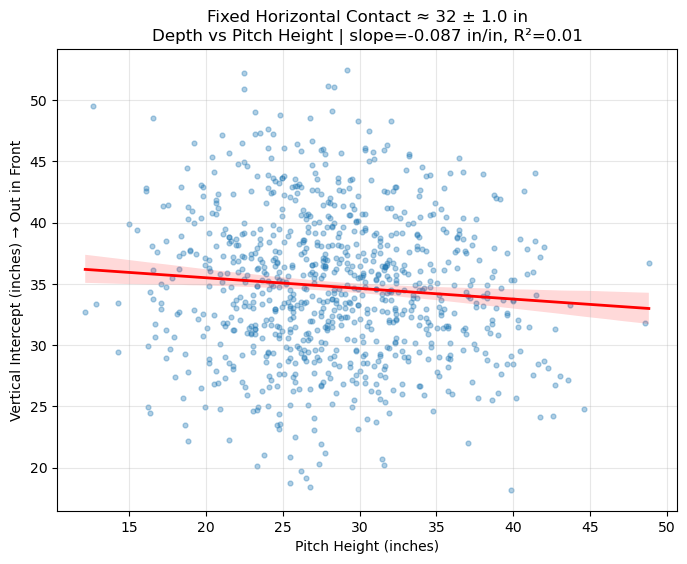

In [35]:
plot_height_vs_depth_at_fixed_horizontal(
    filtered_batted_R,
    x_center=32,
    x_width=2
)

## Positive slope means higher is happening more out in front, negative means lower is happening more out in front

# Now Pitch Type for height

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

def plot_height_vs_depth_at_fixed_horizontal_fastballs(
    filtered_batted,
    x_center,
    x_width=2,
    min_samples=50,
    fastball_types=("FF", "SI", "FT")  # add "FC" if you want cutters
):
    """
    Fastball-only: contact depth vs pitch height
    X-axis = pitch height (inches)
    Slope = in / in
    """

    # Required columns
    cols = [
        "plate_z",
        "pitch_type",
        "intercept_ball_minus_batter_pos_x_inches",
        "intercept_ball_minus_batter_pos_y_inches",
    ]

    df = filtered_batted[cols].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # -----------------------------
    # FILTER: FASTBALLS ONLY
    # -----------------------------
    df = df[df["pitch_type"].isin(fastball_types)]

    # -----------------------------
    # FILTER: FIXED HORIZONTAL BAND
    # -----------------------------
    half = x_width / 2
    band = df[
        df["intercept_ball_minus_batter_pos_x_inches"]
        .between(x_center - half, x_center + half)
    ]

    n = band.shape[0]
    print(f"Fastball samples in horizontal band [{x_center-half}, {x_center+half}]: {n}")

    if n < min_samples:
        print("Not enough fastball samples — widen x_width or lower min_samples.")
        return

    # -----------------------------
    # REGRESSION (in / in)
    # -----------------------------
    X = (band["plate_z"] * 12).values.reshape(-1, 1)   # inches
    y = band["intercept_ball_minus_batter_pos_y_inches"].values

    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]   # in / in
    r2 = model.score(X, y)

    # -----------------------------
    # PLOT
    # -----------------------------
    plt.figure(figsize=(8, 6))
    sns.regplot(
        x=X.flatten(),
        y=y,
        scatter_kws={"alpha": 0.35, "s": 12},
        line_kws={"color": "red", "linewidth": 2},
    )

    plt.xlabel("Pitch Height (inches)")
    plt.ylabel("Vertical Intercept (inches) → Out in Front")
    plt.title(
        f"FASTBALLS ONLY | Fixed Horizontal ≈ {x_center} ± {half} in\n"
        f"Slope = {slope:.3f} in/in | $R^2$ = {r2:.2f} | n = {n}"
    )
    plt.grid(alpha=0.3)
    plt.show()

Fastball samples in horizontal band [31.0, 33.0]: 477


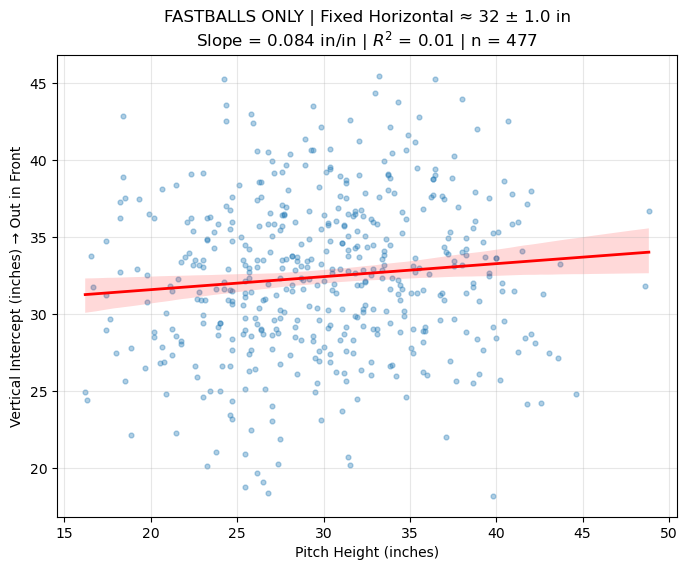

In [37]:
plot_height_vs_depth_at_fixed_horizontal_fastballs(
    filtered_batted_R,
    x_center=32,
    x_width=2
)

## In conclusion, height doesn't really matter when it comes to making contact out in front compared to distance away from the batter